In [ ]:
import torch
import torch.nn as nn

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

NUM_GPUS = torch.cuda.device_count()
print(f'Number of GPUs: {NUM_GPUS}')

for i in range(NUM_GPUS):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')
    print(f'  Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB')

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


PyTorch: 2.10.0+cu128
CUDA available: True
Number of GPUs: 2
  GPU 0: Tesla T4
  Memory: 15.6 GB
  GPU 1: Tesla T4
  Memory: 15.6 GB


In [ ]:
import os

base = '/kaggle/input'
for root, dirs, files in os.walk(base):
    for f in files:
        print(os.path.join(root, f))


/kaggle/input/datasets/prateekanand172/lstgan-data/graph_features.pkl
/kaggle/input/datasets/prateekanand172/lstgan-data/feature_config.pkl
/kaggle/input/datasets/prateekanand172/lstgan-data/adj_mx_bay.pkl
/kaggle/input/datasets/prateekanand172/lstgan-data/temporal_features_val.pkl
/kaggle/input/datasets/prateekanand172/lstgan-data/sensor_ids.txt
/kaggle/input/datasets/prateekanand172/lstgan-data/time_series_train.pkl
/kaggle/input/datasets/prateekanand172/lstgan-data/temporal_features_enhanced_test.pkl
/kaggle/input/datasets/prateekanand172/lstgan-data/graph.pkl
/kaggle/input/datasets/prateekanand172/lstgan-data/distances_bay_2017.csv
/kaggle/input/datasets/prateekanand172/lstgan-data/pems_bay_stations.csv
/kaggle/input/datasets/prateekanand172/lstgan-data/adjacency_matrix.pkl
/kaggle/input/datasets/prateekanand172/lstgan-data/temporal_features_enhanced_train.pkl
/kaggle/input/datasets/prateekanand172/lstgan-data/graph_fixed.pkl
/kaggle/input/datasets/prateekanand172/lstgan-data/pems-

In [ ]:
import os

DATA_DIR = '/kaggle/input/datasets/prateekanand172/lstgan-data'


print('Files in DATA_DIR:')
for f in os.listdir(DATA_DIR):
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / 1e6
    print(f'  {f} ({size_mb:.1f} MB)')


Files in DATA_DIR:
  graph_features.pkl (0.0 MB)
  feature_config.pkl (0.0 MB)
  adj_mx_bay.pkl (1.7 MB)
  temporal_features_val.pkl (0.0 MB)
  sensor_ids.txt (0.0 MB)
  time_series_train.pkl (8.9 MB)
  temporal_features_enhanced_test.pkl (0.1 MB)
  graph.pkl (0.4 MB)
  distances_bay_2017.csv (0.2 MB)
  pems_bay_stations.csv (0.0 MB)
  adjacency_matrix.pkl (1.7 MB)
  temporal_features_enhanced_train.pkl (0.5 MB)
  graph_fixed.pkl (0.4 MB)
  pems-bay.h5 (135.9 MB)
  temporal_features_enhanced_val.pkl (0.1 MB)
  sensor_statistics.pkl (0.1 MB)
  traffic_data.pkl (35.3 MB)
  graph_sensor_ids.txt (0.0 MB)
  distances.csv (0.2 MB)
  temporal_features_train.pkl (0.1 MB)
  pems-bay-meta.h5 (1.1 MB)
  temporal_features_test.pkl (0.0 MB)
  time_series_val.pkl (1.9 MB)
  stations_included.csv (0.0 MB)
  dataset_summary.txt (0.0 MB)
  time_series_test.pkl (1.9 MB)
  traffic_stations.csv (0.0 MB)


In [ ]:
import os, math, time, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

RAW_H5 = os.path.join(DATA_DIR, 'pems-bay.h5')

print('Loading pems-bay.h5 ...')
df = pd.read_hdf(RAW_H5)
print(f'Shape: {df.shape}')

df = df.interpolate(method='linear', axis=0, limit_direction='both')
df = df.fillna(method='ffill').fillna(method='bfill')

total = len(df)
train_end = int(total * 0.7)
val_end = int(total * 0.8)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(f'Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}')

OUT_DIR = '/kaggle/working'
train_df.to_pickle(os.path.join(OUT_DIR, 'train_5min.pkl'))
val_df.to_pickle(os.path.join(OUT_DIR, 'val_5min.pkl'))
test_df.to_pickle(os.path.join(OUT_DIR, 'test_5min.pkl'))
print('5-min Data sliced and saved!')


Loading pems-bay.h5 ...
Shape: (52116, 325)


/tmp/ipykernel_24/347506997.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


Train: (36481, 325), Val: (5211, 325), Test: (10424, 325)
5-min Data sliced and saved!


In [ ]:
import os, math, time, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

GRAPH_FILE = os.path.join(DATA_DIR, 'adj_mx_bay.pkl')
TRAIN_FILE = '/kaggle/working/train_5min.pkl'
VAL_FILE   = '/kaggle/working/val_5min.pkl'
TEST_FILE  = '/kaggle/working/test_5min.pkl'

NUM_SENSORS      = 325
STEPS_PER_HOUR   = 12
STEPS_PER_DAY    = 288

WEEKLY_WINDOW    = 2016
DAILY_WINDOW     = 288
HOURLY_WINDOW    = 12
FORECAST_HORIZON = 12
EVAL_HORIZONS    = [3, 6, 12]

WEEKLY_IN_CHANNELS  = 3;  WEEKLY_OUT_CHANNELS  = 16
DAILY_IN_CHANNELS   = 3;  DAILY_OUT_CHANNELS   = 8
HOURLY_IN_CHANNELS  = 1

WEEKLY_STRIDE_1 = 14; WEEKLY_STRIDE_2 = 12
DAILY_STRIDE_1  = 4;  DAILY_STRIDE_2  = 6

SPATIAL_EMBED_DIM       = 16
GLOBAL_SPATIAL_CHANNELS = 16; GLOBAL_ATTN_HEADS = 4; GLOBAL_ATTN_LAYERS = 1
LOCAL_SPATIAL_CHANNELS  = 8;  CHEBYSHEV_K = 5;      GCN_LAYERS = 1

D_MODEL = WEEKLY_OUT_CHANNELS + DAILY_OUT_CHANNELS + GLOBAL_SPATIAL_CHANNELS + LOCAL_SPATIAL_CHANNELS  # 48
TIME_ONEHOT_DIM = 7 + STEPS_PER_DAY
DECODER_HEADS = 6; DECODER_HEAD_DIM = 8; DECODER_LAYERS = 1

BATCH_SIZE          = 8
LEARNING_RATE       = 0.005
MAX_EPOCHS          = 100
EARLY_STOP_PATIENCE = 10
GRAD_CLIP           = 5.0
WEIGHT_DECAY        = 1e-4
LR_SCHEDULER        = True
LR_PATIENCE         = 5
LR_FACTOR           = 0.5
LR_MIN              = 1e-6

print(f'D_MODEL={D_MODEL}, TIME_DIM={TIME_ONEHOT_DIM}, HORIZON={FORECAST_HORIZON}')
print(f'Weekly: {WEEKLY_WINDOW}→{WEEKLY_WINDOW//WEEKLY_STRIDE_1}→{WEEKLY_WINDOW//WEEKLY_STRIDE_1//WEEKLY_STRIDE_2}')
print(f'Daily:  {DAILY_WINDOW}→{DAILY_WINDOW//DAILY_STRIDE_1}→{DAILY_WINDOW//DAILY_STRIDE_1//DAILY_STRIDE_2}')
print(f'Device: {DEVICE}')


D_MODEL=48, TIME_DIM=295, HORIZON=12
Weekly: 2016→144→12
Daily:  288→72→12
Device: cuda:0


In [ ]:
class TrafficDataset(Dataset):
    """Multi-scale traffic forecasting dataset at 5-min resolution."""
    def __init__(self, data_df, mode='train', mean=None, std=None):
        self.mode = mode
        self.num_sensors = data_df.shape[1]

        self.mean = data_df.values.mean() if mean is None else mean
        self.std  = data_df.values.std()  if std  is None else std
        self.speed = ((data_df.values - self.mean) / (self.std + 1e-8)).astype(np.float32)

        if hasattr(data_df.index, 'weekday'):
            self.day_of_week = data_df.index.weekday.values

            self.time_of_day = (data_df.index.hour * 12 + data_df.index.minute // 5).values
        else:
            T = len(data_df)
            self.day_of_week = np.arange(T) % 7
            self.time_of_day = np.arange(T) % STEPS_PER_DAY

        self.total_steps = len(self.speed)
        self.start_offset = WEEKLY_WINDOW
        self.valid_len = self.total_steps - self.start_offset - FORECAST_HORIZON + 1

        assert self.valid_len > 0, f'Not enough data: {self.total_steps} steps'
        print(f'[{mode}] {self.total_steps} steps, {self.valid_len} samples, {self.num_sensors} sensors')

    def __len__(self):
        return self.valid_len

    def _time_feats(self, idx, length):
        """Extract normalized time features for a window."""
        s = idx - length
        dow = self.day_of_week[s:idx].astype(np.float32) / 6.0
        tod = self.time_of_day[s:idx].astype(np.float32) / 287.0
        return np.stack([dow, tod], axis=-1)

    def __getitem__(self, idx):
        t = self.start_offset + idx
        N = self.num_sensors

        sp_w = self.speed[t-WEEKLY_WINDOW:t]
        tf_w = self._time_feats(t, WEEKLY_WINDOW)
        X_w = np.stack([
            sp_w,
            np.tile(tf_w[:, 0:1], (1, N)),
            np.tile(tf_w[:, 1:2], (1, N))
        ], axis=-1)

        sp_d = self.speed[t-DAILY_WINDOW:t]
        tf_d = self._time_feats(t, DAILY_WINDOW)
        X_d = np.stack([
            sp_d,
            np.tile(tf_d[:, 0:1], (1, N)),
            np.tile(tf_d[:, 1:2], (1, N))
        ], axis=-1)

        X_h = self.speed[t-HOURLY_WINDOW:t][:, :, np.newaxis]

        t_info = np.array([self.day_of_week[t], self.time_of_day[t]], dtype=np.int64)

        Y = self.speed[t:t+FORECAST_HORIZON][:, :, np.newaxis]

        return (
            torch.from_numpy(X_w),
            torch.from_numpy(X_d),
            torch.from_numpy(X_h),
            torch.from_numpy(t_info),
            torch.from_numpy(Y)
        )


def load_adjacency_matrix(path=GRAPH_FILE):
    with open(path, 'rb') as f:
        adj = pickle.load(f, encoding='latin1')

    if isinstance(adj, (tuple, list)):
        adj = adj[2] if len(adj) >= 3 else adj[-1]

    return adj.astype(np.float32) if isinstance(adj, np.ndarray) else adj


def get_edge_info(adj_mx):
    rows, cols = np.nonzero(adj_mx)
    edge_index = torch.LongTensor(np.stack([rows, cols]))
    edge_weight = torch.FloatTensor(adj_mx[rows, cols])
    return edge_index, edge_weight


def build_dataloaders(batch_size=BATCH_SIZE):
    print('Loading data')

    train_df = pd.read_pickle(TRAIN_FILE)
    val_df   = pd.read_pickle(VAL_FILE)
    test_df  = pd.read_pickle(TEST_FILE)
    adj_mx   = load_adjacency_matrix()

    print(f'Adj matrix: {adj_mx.shape}')
    print(f'Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}')

    train_mean = train_df.values.mean()
    train_std = train_df.values.std()
    print(f'Train stats: mean={train_mean:.2f}, std={train_std:.2f}')

    train_ds = TrafficDataset(train_df, 'train', train_mean, train_std)
    val_ds   = TrafficDataset(val_df,   'val',   train_mean, train_std)
    test_ds  = TrafficDataset(test_df,  'test',  train_mean, train_std)

    kw = dict(num_workers=4, pin_memory=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True, **kw)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw)

    edge_index, edge_weight = get_edge_info(adj_mx)

    return train_loader, val_loader, test_loader, edge_index, edge_weight, train_mean, train_std, adj_mx

print('Dataset module ready.')

Dataset module ready.


In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class TemporalEncoder(nn.Module):
    """Conv1D downsampling with two blocks."""
    def __init__(self, in_ch, out_ch, s1, s2):
        super().__init__()
        mid = max((in_ch + out_ch)//2, 8)

        self.c1a = nn.Conv1d(in_ch, mid, 3, padding=1)
        self.c1b = nn.Conv1d(mid, mid, s1, stride=s1) if s1>1 else nn.Identity()
        self.bn1 = nn.BatchNorm1d(mid)

        self.c2a = nn.Conv1d(mid, out_ch, 3, padding=1)
        self.c2b = nn.Conv1d(out_ch, out_ch, s2, stride=s2) if s2>1 else nn.Identity()
        self.bn2 = nn.BatchNorm1d(out_ch)

    def forward(self, x):
        B, T, N, C = x.shape
        x = x.permute(0, 2, 3, 1).reshape(B*N, C, T)

        x = F.relu(self.c1a(x))
        x = self.c1b(x)
        x = F.relu(self.bn1(x))

        x = F.relu(self.c2a(x))
        x = self.c2b(x)
        x = self.bn2(x)

        _, Co, To = x.shape
        return x.reshape(B, N, Co, To).permute(0, 3, 1, 2)


class SpatialEmbedding(nn.Module):
    def __init__(self, in_ch=1, out_ch=24):
        super().__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, 1)
        self.bn = nn.BatchNorm1d(out_ch)

    def forward(self, x):
        B, T, N, C = x.shape
        x = x.reshape(B*T, N, C).permute(0, 2, 1)
        x = self.bn(self.conv(x))
        return x.permute(0, 2, 1).reshape(B, T, N, -1)


class GlobalSpatialEncoder(nn.Module):
    def __init__(self, d=24, heads=8, nl=2, out_ch=24):
        super().__init__()
        self.layers = nn.ModuleList()

        for _ in range(nl):
            self.layers.append(nn.ModuleDict({
                'attn': nn.MultiheadAttention(d, heads, batch_first=True, dropout=0.05),
                'n1': nn.LayerNorm(d),
                'n2': nn.LayerNorm(d),
                'ffn': nn.Sequential(
                    nn.Linear(d, d*4),
                    nn.GELU(),
                    nn.Dropout(0.05),
                    nn.Linear(d*4, d)
                )
            }))

        self.proj = nn.Linear(d, out_ch) if d != out_ch else nn.Identity()

    def forward(self, x):
        B, T, N, C = x.shape
        x = x.reshape(B*T, N, C)

        for l in self.layers:
            a, _ = l['attn'](x, x, x)
            x = l['n1'](x + a)

            x = l['n2'](x + l['ffn'](x))

        return self.proj(x).reshape(B, T, N, -1)


class ManualChebConv(nn.Module):
    def __init__(self, in_ch, out_ch, K=5):
        super().__init__()
        self.K = K
        self.weights = nn.ParameterList([
            nn.Parameter(torch.empty(in_ch, out_ch)) for _ in range(K)
        ])
        self.bias = nn.Parameter(torch.zeros(out_ch))

        for w in self.weights:
            nn.init.xavier_uniform_(w)

    def forward(self, x, L):
        Z0, Z1 = x, L @ x
        out = Z0 @ self.weights[0]

        if self.K > 1:
            out = out + Z1 @ self.weights[1]

        for k in range(2, self.K):
            Zk = 2 * L @ Z1 - Z0
            out = out + Zk @ self.weights[k]
            Z0, Z1 = Z1, Zk

        return out + self.bias


class LocalSpatialEncoder(nn.Module):
    def __init__(self, in_ch=24, out_ch=12, K=5):
        super().__init__()
        self.cheb = ManualChebConv(in_ch, out_ch, K)
        self.register_buffer('L_scaled', None)

    def set_graph(self, adj_mx):
        A = adj_mx
        D_inv = np.diag(1.0 / np.sqrt(np.maximum(A.sum(1), 1e-8)))
        L = np.eye(A.shape[0]) - D_inv @ A @ D_inv
        eig = np.linalg.eigvalsh(L)

        device = next(self.parameters()).device
        L_scaled = 2 * L / (eig[-1] + 1e-8) - np.eye(A.shape[0])
        self.L_scaled = torch.FloatTensor(L_scaled).to(device)

    def forward(self, x, edge_index=None, edge_weight=None):
        B, T, N, C = x.shape
        L = self.L_scaled.to(x.device)

        x = x.reshape(B*T, N, C)
        out = self.cheb(x, L)

        return out.reshape(B, T, N, -1)


class TimeEncoder(nn.Module):
    def __init__(self, d=72, tdim=295):
        super().__init__()
        h = d * 2
        self.mlp = nn.Sequential(
            nn.Linear(tdim, h),
            nn.Linear(h, h),
            nn.ReLU(),
            nn.Linear(h, d)
        )
        self.norm = nn.LayerNorm(d)

    def forward(self, ste, time_info):
        B, T, N, d = ste.shape

        dow = F.one_hot(time_info[:, 0].long(), 7).float()
        tod = F.one_hot(time_info[:, 1].long(), 288).float()

        vt = self.mlp(torch.cat([dow, tod], -1))

        vt = vt[:, None, None, :].expand_as(ste)

        return self.norm(ste + vt)

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""
    def __init__(self, d, maxlen=500):
        super().__init__()
        pe = torch.zeros(maxlen, d)
        pos = torch.arange(maxlen).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TemporalDecoder(nn.Module):
    """Self-attention decoder with cross-attention for forecasting."""
    def __init__(self, d=72, heads=8, nl=2, H=12):
        super().__init__()
        self.H = H
        self.pe = PositionalEncoding(d)

        self.enc_layers = nn.ModuleList()
        self.dec_layers = nn.ModuleList()

        for _ in range(nl):
            self.enc_layers.append(nn.ModuleDict({
                'attn': nn.MultiheadAttention(d, heads, batch_first=True, dropout=0.05),
                'n1': nn.LayerNorm(d),
                'n2': nn.LayerNorm(d),
                'ffn': nn.Sequential(
                    nn.Linear(d, d*4),
                    nn.GELU(),
                    nn.Dropout(0.05),
                    nn.Linear(d*4, d)
                )
            }))

            self.dec_layers.append(nn.ModuleDict({
                'attn': nn.MultiheadAttention(d, heads, batch_first=True, dropout=0.05),
                'n1': nn.LayerNorm(d),
                'n2': nn.LayerNorm(d),
                'ffn': nn.Sequential(
                    nn.Linear(d, d*4),
                    nn.GELU(),
                    nn.Dropout(0.05),
                    nn.Linear(d*4, d)
                )
            }))

        self.fq = nn.Parameter(torch.randn(1, H, d) * 0.02)

        self.out_proj = nn.Linear(d, 1)

    def forward(self, ste):
        B, T, N, d = ste.shape

        x = ste.permute(0, 2, 1, 3).reshape(B*N, T, d)

        x = self.pe(x)

        for l in self.enc_layers:
            a, _ = l['attn'](x, x, x)
            x = l['n1'](x + a)
            x = l['n2'](x + l['ffn'](x))

        q = self.fq.expand(B*N, -1, -1)

        for l in self.dec_layers:
            a, _ = l['attn'](q, x, x)
            q = l['n1'](q + a)
            q = l['n2'](q + l['ffn'](q))


        out = self.out_proj(q)

        return out.reshape(B, N, self.H, 1).permute(0, 2, 1, 3)

class LSTGAN(nn.Module):
    def __init__(self, num_sensors=325):
        super().__init__()

        try:
            weekly_out = WEEKLY_OUT_CHANNELS
            daily_out = DAILY_OUT_CHANNELS
            spatial_dim = SPATIAL_EMBED_DIM
            global_ch = GLOBAL_SPATIAL_CHANNELS
            local_ch = LOCAL_SPATIAL_CHANNELS
            d_model = D_MODEL
        except NameError:

            weekly_out = 24
            daily_out = 12
            spatial_dim = 24
            global_ch = 24
            local_ch = 12
            d_model = 72

        self.weekly_enc = TemporalEncoder(3, weekly_out, 14, 12)
        self.daily_enc = TemporalEncoder(3, daily_out, 4, 6)

        self.sp_embed = SpatialEmbedding(1, spatial_dim)
        self.global_enc = GlobalSpatialEncoder(spatial_dim, 8, 2, global_ch)
        self.local_enc = LocalSpatialEncoder(spatial_dim, local_ch, 5)

        self.time_enc = TimeEncoder(d_model, 295)
        self.decoder = TemporalDecoder(d_model, 8, 2, 12)

    def _match_time(self, x, tgt):
        T = x.shape[1]
        if T == tgt:
            return x
        if T > tgt:
            return x[:, :tgt]

        B, T, N, C = x.shape
        x = x.permute(0, 3, 2, 1).reshape(B*C*N, 1, T)
        x = F.interpolate(x, size=tgt, mode='nearest')
        return x.reshape(B, C, N, tgt).permute(0, 3, 2, 1)

    def forward(self, X_w, X_d, X_h, t_info, edge_idx=None, edge_wt=None):

        Xw = self.weekly_enc(X_w)
        Xd = self.daily_enc(X_d)

        Xe = self.sp_embed(X_h)
        Xsa = self.global_enc(Xe)
        Xgcn = self.local_enc(Xe)

        Tt = X_h.shape[1]
        Xw = self._match_time(Xw, Tt)
        Xd = self._match_time(Xd, Tt)

        STe = torch.cat([Xw, Xd, Xsa, Xgcn], dim=-1)

        STE = self.time_enc(STe, t_info)

        return self.decoder(STE)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('All model components defined.')


All model components defined.


In [ ]:
class LSTGAN(nn.Module):
    def __init__(self, num_sensors=NUM_SENSORS):
        super().__init__()
        self.weekly_enc  = TemporalEncoder(WEEKLY_IN_CHANNELS, WEEKLY_OUT_CHANNELS, WEEKLY_STRIDE_1, WEEKLY_STRIDE_2)
        self.daily_enc   = TemporalEncoder(DAILY_IN_CHANNELS, DAILY_OUT_CHANNELS, DAILY_STRIDE_1, DAILY_STRIDE_2)
        self.sp_embed    = SpatialEmbedding(HOURLY_IN_CHANNELS, SPATIAL_EMBED_DIM)
        self.global_enc  = GlobalSpatialEncoder(SPATIAL_EMBED_DIM, GLOBAL_ATTN_HEADS, GLOBAL_ATTN_LAYERS, GLOBAL_SPATIAL_CHANNELS)
        self.local_enc   = LocalSpatialEncoder(SPATIAL_EMBED_DIM, LOCAL_SPATIAL_CHANNELS, CHEBYSHEV_K)
        self.time_enc    = TimeEncoder(D_MODEL)
        self.decoder     = TemporalDecoder(D_MODEL, DECODER_HEADS, DECODER_LAYERS, FORECAST_HORIZON)

    def _match_time(self, x, tgt):
        T = x.shape[1]
        if T == tgt: return x
        if T > tgt: return x[:,:tgt]
        B,T,N,C = x.shape
        x = x.permute(0,3,2,1).reshape(B*C*N,1,T)
        x = F.interpolate(x, size=tgt, mode='nearest')
        return x.reshape(B,C,N,tgt).permute(0,3,2,1)

    def forward(self, X_w, X_d, X_h, t_info, edge_idx=None, edge_wt=None):
        Xw = self.weekly_enc(X_w)
        Xd = self.daily_enc(X_d)
        Xe = self.sp_embed(X_h)
        Xsa = self.global_enc(Xe)
        Xgcn = self.local_enc(Xe, edge_idx, edge_wt)
        Tt = X_h.shape[1]
        Xw = self._match_time(Xw, Tt)
        Xd = self._match_time(Xd, Tt)
        STe = torch.cat([Xw, Xd, Xsa, Xgcn], dim=-1)
        STE = self.time_enc(STe, t_info)
        return self.decoder(STE)

model = LSTGAN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'LSTGAN parameters: {n_params:,} (~{n_params*4/1024/1024:.1f} MB)')

LSTGAN parameters: 109,428 (~0.4 MB)


In [ ]:
train_loader, val_loader, test_loader, edge_index, edge_weight, train_mean, train_std, adj_mx = build_dataloaders(BATCH_SIZE)

if hasattr(model, 'module'):
    model.module.local_enc.set_graph(adj_mx)
else:
    model.local_enc.set_graph(adj_mx)


edge_index = edge_index.to(DEVICE)
edge_weight = edge_weight.to(DEVICE)

print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Loading data...
Adj matrix: (325, 325)
Train: (36481, 325), Val: (5211, 325), Test: (10424, 325)
Train stats: mean=62.74, std=9.44
[train] 36481 steps, 34454 samples, 325 sensors
[val] 5211 steps, 3184 samples, 325 sensors
[test] 10424 steps, 8397 samples, 325 sensors

Train batches: 4306
Val batches:   398
Test batches:  1050


In [ ]:
def masked_mae(p, t, mv=0.0):
    m = (t != mv)
    return torch.abs(p[m]-t[m]).mean() if m.sum()>0 else torch.tensor(0.0, device=p.device)

def masked_mape(p, t, mv=0.0):
    m = (t != mv) & (t.abs() > 1e-4)
    return (torch.abs(p[m]-t[m])/t[m].abs()).mean().item()*100 if m.sum()>0 else 0.0

def masked_rmse(p, t, mv=0.0):
    m = (t != mv)
    return torch.sqrt(((p[m]-t[m])**2).mean()) if m.sum()>0 else torch.tensor(0.0, device=p.device)

@torch.no_grad()
def evaluate(model, loader, mean, std):
    model.eval()
    maes, mapes, rmses = [], [], []
    h_metrics = {h: {'mae':[],'mape':[],'rmse':[]} for h in EVAL_HORIZONS}
    for batch in loader:
        Xw,Xd,Xh,ti,Y = [b.to(DEVICE) for b in batch]
        pred = model(Xw,Xd,Xh,ti,edge_index,edge_weight)
        pd_ = pred*std+mean; yd = Y*std+mean
        maes.append(masked_mae(pd_,yd).item())
        mapes.append(masked_mape(pd_,yd))
        rmses.append(masked_rmse(pd_,yd).item())
        for h in EVAL_HORIZONS:
            if h <= pred.shape[1]:
                ph,yh = pd_[:,h-1:h],yd[:,h-1:h]
                h_metrics[h]['mae'].append(masked_mae(ph,yh).item())
                h_metrics[h]['mape'].append(masked_mape(ph,yh))
                h_metrics[h]['rmse'].append(masked_rmse(ph,yh).item())
    hr = {h:{k:np.mean(v) for k,v in hm.items()} for h,hm in h_metrics.items()}
    return np.mean(maes), np.mean(mapes), np.mean(rmses), hr

print('Metrics ready.')

Metrics ready.


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE, min_lr=LR_MIN)
criterion = nn.L1Loss()
scaler = torch.amp.GradScaler('cuda')

best_val_mae = float('inf')
patience_counter = 0
history = {'train_loss':[], 'val_mae':[], 'val_mape':[], 'val_rmse':[], 'lr':[]}

CKPT_PATH = '/kaggle/working/best_lstgan.pt'
start_epoch = 1

import os
if os.path.exists(CKPT_PATH):
    print(f"Found existing checkpoint: {CKPT_PATH}. Resuming training!")
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)

    model_to_load = model.module if hasattr(model, 'module') else model
    model_to_load.load_state_dict(ckpt['model'])

    if 'opt' in ckpt:
        optimizer.load_state_dict(ckpt['opt'])

    start_epoch = ckpt['epoch'] + 1
    best_val_mae = ckpt['val_mae']
    print(f"Resuming from Epoch {start_epoch} | Previous Best MAE: {best_val_mae:.4f}")
else:
    print("No checkpoint found. Starting from scratch.")

print(f'\nTraining LSTGAN for up to {MAX_EPOCHS} epochs...')
print(f'Batch size: {BATCH_SIZE}, LR: {LEARNING_RATE}, Weight decay: {WEIGHT_DECAY}')

for epoch in range(start_epoch, MAX_EPOCHS+1):
    t0 = time.time()
    model.train()
    losses = []
    for batch in train_loader:
        Xw,Xd,Xh,ti,Y = [b.to(DEVICE) for b in batch]
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            pred = model(Xw,Xd,Xh,ti,edge_index,edge_weight)
            loss = criterion(pred, Y)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        losses.append(loss.item())

    train_loss = np.mean(losses)
    val_mae, val_mape, val_rmse, val_h = evaluate(model, val_loader, train_mean, train_std)
    scheduler.step(val_mae)
    lr_now = optimizer.param_groups[0]['lr']
    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_mae'].append(val_mae)
    history['val_mape'].append(val_mape)
    history['val_rmse'].append(val_rmse)
    history['lr'].append(lr_now)

    marker = ''
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        patience_counter = 0
        model_to_save = model.module if hasattr(model, 'module') else model
        torch.save({'epoch':epoch, 'model':model_to_save.state_dict(), 'opt':optimizer.state_dict(),
                    'val_mae':val_mae, 'mean':train_mean, 'std':train_std}, CKPT_PATH)

        marker = ' BEST'
    else:
        patience_counter += 1

    print(f'Ep {epoch:3d}/{MAX_EPOCHS} | Loss {train_loss:.4f} | '
          f'MAE {val_mae:.4f} | MAPE {val_mape:.2f}% | RMSE {val_rmse:.4f} | '
          f'LR {lr_now:.1e} | {elapsed:.1f}s{marker}')

    if epoch % 10 == 0 or epoch == 1:
        for h in EVAL_HORIZONS:
            r = val_h[h]
            print(f'  H{h}: MAE={r["mae"]:.4f} MAPE={r["mape"]:.2f}% RMSE={r["rmse"]:.4f}')

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'\n Early stopping at epoch {epoch} (no improvement for {EARLY_STOP_PATIENCE} epochs)')
        break

print(f'\n Training complete Best Val MAE: {best_val_mae:.4f}')


No checkpoint found. Starting from scratch.

Training LSTGAN for up to 100 epochs...
Batch size: 8, LR: 0.005, Weight decay: 0.0001
Ep   1/100 | Loss 0.2037 | MAE 1.7940 | MAPE 4.14% | RMSE 3.4370 | LR 5.0e-03 | 395.3s BEST
  H3: MAE=1.5227 MAPE=3.30% RMSE=2.7929
  H6: MAE=1.8767 MAPE=4.30% RMSE=3.5266
  H12: MAE=2.1575 MAPE=5.24% RMSE=4.0711
Ep   2/100 | Loss 0.1795 | MAE 1.7478 | MAPE 4.08% | RMSE 3.4399 | LR 5.0e-03 | 394.1s BEST
Ep   3/100 | Loss 0.1747 | MAE 1.7233 | MAPE 4.04% | RMSE 3.4443 | LR 5.0e-03 | 393.9s BEST
Ep   4/100 | Loss 0.1719 | MAE 1.7160 | MAPE 4.23% | RMSE 3.4264 | LR 5.0e-03 | 393.7s BEST
Ep   5/100 | Loss 0.1703 | MAE 1.7339 | MAPE 4.18% | RMSE 3.4448 | LR 5.0e-03 | 395.9s
Ep   6/100 | Loss 0.1690 | MAE 1.6875 | MAPE 3.98% | RMSE 3.3606 | LR 5.0e-03 | 394.9s BEST
Ep   7/100 | Loss 0.1676 | MAE 1.6573 | MAPE 3.81% | RMSE 3.3136 | LR 5.0e-03 | 394.4s BEST
Ep   8/100 | Loss 0.1671 | MAE 1.6627 | MAPE 3.88% | RMSE 3.3261 | LR 5.0e-03 | 396.4s
Ep   9/100 | Loss 0.1

## 9. Training Curves

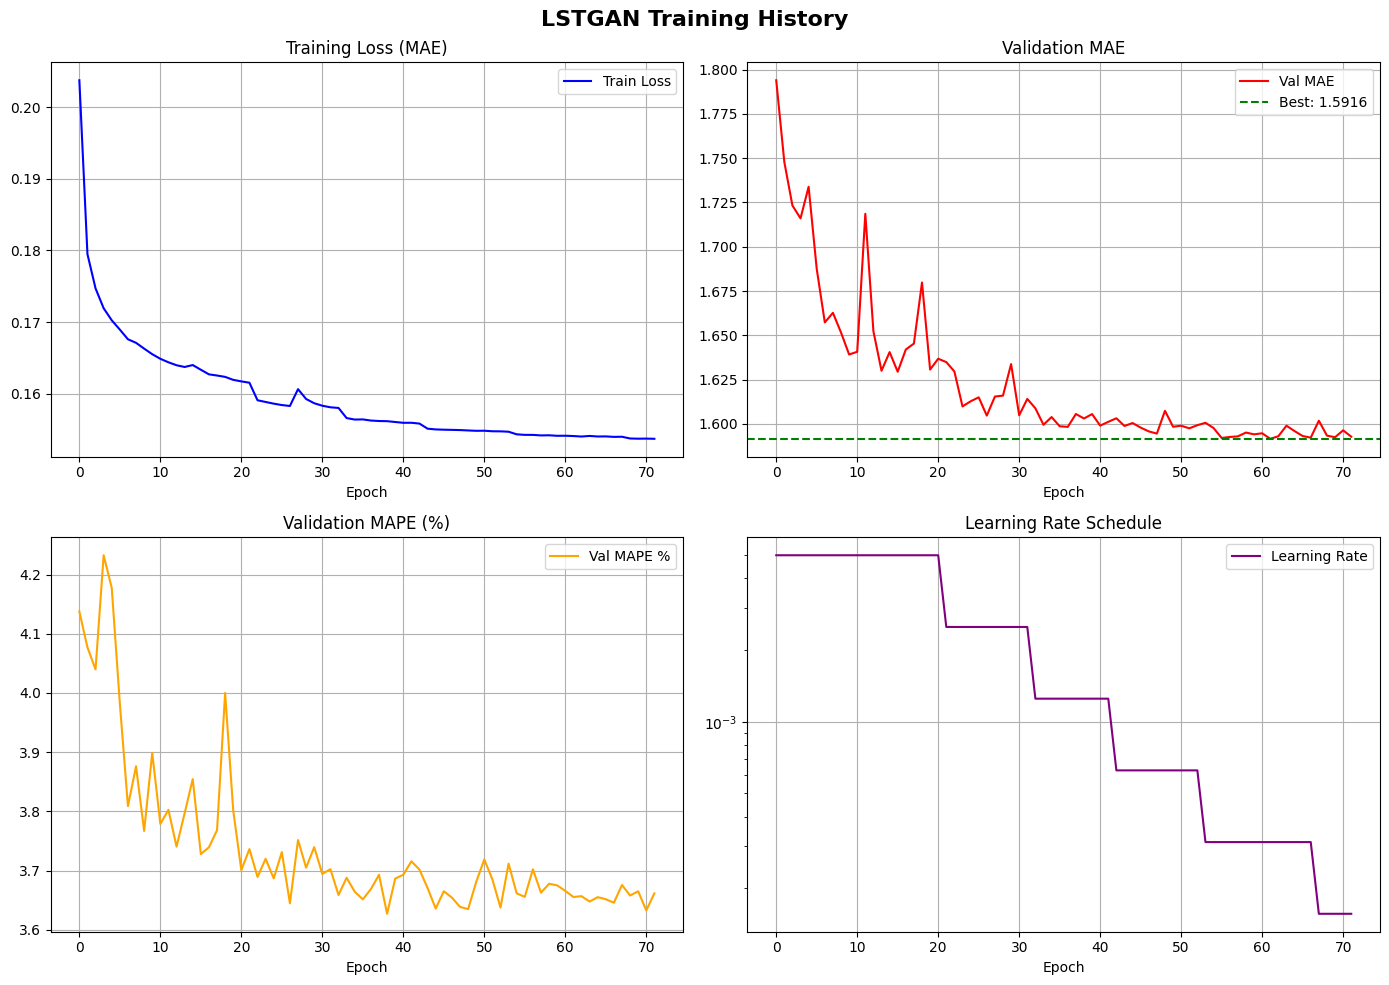

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LSTGAN Training History', fontsize=16, fontweight='bold')

axes[0,0].plot(history['train_loss'], 'b-', label='Train Loss')
axes[0,0].set_title('Training Loss (MAE)'); axes[0,0].set_xlabel('Epoch'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(history['val_mae'], 'r-', label='Val MAE')
axes[0,1].axhline(best_val_mae, color='g', linestyle='--', label=f'Best: {best_val_mae:.4f}')
axes[0,1].set_title('Validation MAE'); axes[0,1].set_xlabel('Epoch'); axes[0,1].legend(); axes[0,1].grid(True)

axes[1,0].plot(history['val_mape'], 'orange', label='Val MAPE %')
axes[1,0].set_title('Validation MAPE (%)'); axes[1,0].set_xlabel('Epoch'); axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(history['lr'], 'purple', label='Learning Rate')
axes[1,1].set_title('Learning Rate Schedule'); axes[1,1].set_xlabel('Epoch'); axes[1,1].set_yscale('log'); axes[1,1].legend(); axes[1,1].grid(True)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

In [ ]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model'])
print(f'Loaded best model from epoch {ckpt["epoch"]} (Val MAE: {ckpt["val_mae"]:.4f})')

test_mae, test_mape, test_rmse, test_h = evaluate(model, test_loader, train_mean, train_std)

print('       FINAL TEST RESULTS')
print(f'  Overall:  MAE = {test_mae:.4f}  |  MAPE = {test_mape:.2f}%  |  RMSE = {test_rmse:.4f}')
for h in EVAL_HORIZONS:
    r = test_h[h]
    print(f'  Horizon {h}h: MAE = {r["mae"]:.4f}  |  MAPE = {r["mape"]:.2f}%  |  RMSE = {r["rmse"]:.4f}')

Loaded best model from epoch 62 (Val MAE: 1.5916)
       FINAL TEST RESULTS
  Overall:  MAE = 1.5236  |  MAPE = 3.44%  |  RMSE = 3.1094
  Horizon 3h: MAE = 1.3102  |  MAPE = 2.74%  |  RMSE = 2.5179
  Horizon 6h: MAE = 1.5937  |  MAPE = 3.61%  |  RMSE = 3.1896
  Horizon 12h: MAE = 1.8139  |  MAPE = 4.32%  |  RMSE = 3.6459


In [ ]:
import shutil
SAVE_DIR = '/content/drive/MyDrive/LSTGAN_Data/results'
os.makedirs(SAVE_DIR, exist_ok=True)
shutil.copy(CKPT_PATH, os.path.join(SAVE_DIR, 'best_lstgan.pt'))
shutil.copy('/content/training_curves.png', os.path.join(SAVE_DIR, 'training_curves.png'))

with open(os.path.join(SAVE_DIR, 'results.txt'), 'w') as f:
    f.write(f'LSTGAN Test Results\n{"="*40}\n')
    f.write(f'Overall: MAE={test_mae:.4f} MAPE={test_mape:.2f}% RMSE={test_rmse:.4f}\n')
    for h in EVAL_HORIZONS:
        r = test_h[h]
        f.write(f'H{h}: MAE={r["mae"]:.4f} MAPE={r["mape"]:.2f}% RMSE={r["rmse"]:.4f}\n')
    f.write(f'\nBest epoch: {ckpt["epoch"]}\nParams: {n_params:,}\n')

print(f' Results saved to {SAVE_DIR}/')

 Results saved to /content/drive/MyDrive/LSTGAN_Data/results/
